
# SuperbCommand – Multi-Asset CTA Strategy
## Notebook 04C — Standby Put-Option Hedge Research

**Purpose:** investigate whether the original SuperbCommand **Standby Holding Mode** can be used as a trigger for temporary downside protection through put options.

This is an **experimental side branch** and does not alter the main notebook sequence.

### Core hypothesis

In the original SuperbCommand logic, Standby begins when:

- the strategic position is still held;
- the oscillator is below its Lower Bollinger Band; and
- Adaptive SuperTrend is bearish.

The model then allows a fixed recovery window before a full strategic exit.

This creates a natural question:

> **Can a temporary put hedge improve risk-adjusted performance during this vulnerable holding period?**

### Put-entry rule

A new put is purchased at each confirmed:

`standby_anchor_event`

The first experiment uses an **ATM European put** on the original underlying.

### Put-exit rules

The notebook tests several fixed, non-optimised exit conventions:

1. close 1 week after Standby begins;
2. close 2 weeks after Standby begins;
3. close 4 weeks after Standby begins;
4. close 8 weeks after Standby begins;
5. close when Standby itself ends;
6. close 2 weeks after Standby ends;
7. close 4 weeks after Standby ends.

### Critical limitation

Yahoo Finance does not provide a usable historical options-chain database for this project.

Therefore Notebook 04C uses a **synthetic Black–Scholes put revaluation model**, based on:

- contemporaneous underlying price;
- rolling realised volatility;
- fixed option maturity;
- simple risk-free-rate assumption;
- no dividend yield.

This is an exploratory **signal/hedging experiment**, not a production-quality historical options backtest.

If the idea looks promising, a later implementation should use genuine historical option-chain data or exchange-listed option/futures-option data.


In [1]:

# ============================================================
# 4C.1 — IMPORTS, DRIVE & CONFIGURATION
# ============================================================
from __future__ import annotations

import json
import math
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_ROOT = (
    Path("/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy")
    if IN_COLAB
    else Path.cwd() / "Multi-Asset CTA Strategy"
)

CONFIG_PATH = PROJECT_ROOT / "config" / "project_config.json"
if not CONFIG_PATH.exists():
    raise FileNotFoundError("Run Notebook 00 first.")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = json.load(f)

PATHS = {k: Path(v) for k, v in CFG["paths"].items()}
RESEARCH_END = pd.Timestamp(CFG["research_dates"]["research_end"])
HOLDOUT_START = pd.Timestamp(CFG["research_dates"]["holdout_start"])

if CFG["research_dates"]["unlock_holdout"]:
    raise RuntimeError("Notebook 04C cannot run with the holdout unlocked.")

SIGNAL_PATH = PATHS["data_processed"] / "superbcommand_weekly_signal_panel.parquet"
META_PATH = PATHS["data_processed"] / "prototype_universe_metadata.csv"

if not SIGNAL_PATH.exists():
    raise FileNotFoundError("Run Notebook 02 first.")
if not META_PATH.exists():
    raise FileNotFoundError("Run Notebook 01 first.")

panel = pd.read_parquet(SIGNAL_PATH)
meta = pd.read_csv(META_PATH, index_col=0)

try:
    panel = panel.reorder_levels(["date", "ticker"]).sort_index()
except Exception:
    panel = panel.sort_index()

if panel.index.get_level_values("date").max() >= HOLDOUT_START:
    raise RuntimeError("Holdout contamination detected.")

tickers = sorted(panel.index.get_level_values("ticker").unique())

print("Markets:", len(tickers))
print("Research cutoff:", RESEARCH_END.date())
print("2026 holdout: LOCKED")


Mounted at /content/drive
Markets: 11
Research cutoff: 2025-12-31
2026 holdout: LOCKED



## 4C.2 Fixed synthetic-option assumptions

These assumptions are deliberately coarse and **not optimised**.

The aim is to determine whether the Standby state contains enough downside information for put protection to be economically interesting at all.

Initial assumptions:

- ATM strike at entry;
- 26-week maturity;
- 13-week realised-volatility estimate;
- 5% annual volatility floor;
- 150% annual volatility cap;
- 3% constant annual risk-free rate;
- zero dividend yield;
- put notional equal to 25% of the underlying position;
- 5 bps one-way option transaction-cost proxy on option premium.

The hedge size is intentionally modest.


In [2]:

# ============================================================
# 4C.2 — SYNTHETIC OPTION SETTINGS
# ============================================================
OPTION_MATURITY_WEEKS = 26
VOL_LOOKBACK_WEEKS = 13
VOL_FLOOR = 0.05
VOL_CAP = 1.50
RISK_FREE_RATE = 0.03
DIVIDEND_YIELD = 0.00

PUT_HEDGE_NOTIONAL = 0.25
OPTION_COST_BPS = 5.0
OPTION_COST_RATE = OPTION_COST_BPS / 10_000

FIXED_EXIT_WEEKS_FROM_ANCHOR = [1, 2, 4, 8]
POST_STANDBY_EXIT_WEEKS = [2, 4]

print("Synthetic put settings loaded.")


Synthetic put settings loaded.


## 4C.3 Black–Scholes put valuation

In [3]:

# ============================================================
# 4C.3 — BLACK-SCHOLES FUNCTIONS
# ============================================================
def bs_put_price(S, K, T, r, sigma, q=0.0):
    if any(pd.isna(v) for v in [S, K, T, r, sigma]):
        return np.nan
    if S <= 0 or K <= 0:
        return np.nan
    if T <= 0:
        return max(K - S, 0.0)
    sigma = max(float(sigma), 1e-8)

    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    return (
        K * np.exp(-r * T) * norm.cdf(-d2)
        - S * np.exp(-q * T) * norm.cdf(-d1)
    )



## 4C.4 Build weekly volatility estimates

The synthetic option model uses only information available at each date.

Weekly realised volatility is annualised as:

\[
\sigma_t
=
Std(r_{t-12},...,r_t)\sqrt{52}
\]

and clipped to conservative minimum/maximum bounds.


In [4]:

# ============================================================
# 4C.4 — VOLATILITY ESTIMATION
# ============================================================
market_data = {}

for ticker in tickers:
    x = panel.xs(ticker, level="ticker").copy()
    x["underlying_return"] = x["close"].pct_change(fill_method=None)
    x["realised_vol"] = (
        x["underlying_return"]
        .rolling(VOL_LOOKBACK_WEEKS, min_periods=VOL_LOOKBACK_WEEKS)
        .std(ddof=1)
        * np.sqrt(52)
    )
    x["realised_vol"] = x["realised_vol"].clip(VOL_FLOOR, VOL_CAP)
    market_data[ticker] = x

print("Volatility estimates prepared.")


Volatility estimates prepared.



## 4C.5 Identify individual Standby episodes

Each Standby episode starts at `standby_anchor_event`.

It ends at the first subsequent week where `standby_active` is False.

The notebook records both:

- natural Standby end;
- whether that end coincides with a full strategic exit.


In [5]:

# ============================================================
# 4C.5 — EXTRACT STANDBY EPISODES
# ============================================================
episodes = []

for ticker, x in market_data.items():
    idx = x.index

    anchors = np.flatnonzero(x["standby_anchor_event"].to_numpy(dtype=bool))

    for n, start_i in enumerate(anchors, start=1):
        end_i = None

        for j in range(start_i + 1, len(x)):
            if not bool(x["standby_active"].iat[j]):
                end_i = j
                break

        if end_i is None:
            end_i = len(x) - 1

        episodes.append({
            "ticker": ticker,
            "asset_class": meta.loc[ticker, "asset_class"],
            "episode": n,
            "start_i": start_i,
            "end_i": end_i,
            "start_date": idx[start_i],
            "end_date": idx[end_i],
            "standby_weeks_observed": max(end_i - start_i, 0),
            "strategic_exit_at_end": bool(x["position_exit_event"].iat[end_i]),
        })

episodes = pd.DataFrame(episodes)

print("Standby episodes:", len(episodes))
display(episodes.head(20))


Standby episodes: 94


,ticker,asset_class,episode,start_i,end_i,start_date,end_date,standby_weeks_observed,strategic_exit_at_end
0,BTC-USD,crypto,1,200,208,2018-07-20,2018-09-14,8,True
1,BTC-USD,crypto,2,289,295,2020-04-03,2020-05-15,6,False
2,BTC-USD,crypto,3,383,391,2022-01-21,2022-03-18,8,True
3,BTC-USD,crypto,4,582,588,2025-11-14,2025-12-26,6,False
4,DBC,commodities,1,137,145,2008-09-26,2008-11-21,8,True
5,DBC,commodities,2,295,303,2011-10-07,2011-12-02,8,True
6,DBC,commodities,3,330,337,2012-06-08,2012-07-27,7,False
7,DBC,commodities,4,374,382,2013-04-12,2013-06-07,8,True
8,DBC,commodities,5,450,458,2014-09-26,2014-11-21,8,True
9,DBC,commodities,6,667,675,2018-11-23,2019-01-18,8,True



## 4C.6 Synthetic put trade construction

At each Standby anchor:

- strike \(K\) = underlying close at the anchor;
- maturity = 26 weeks;
- premium = Black–Scholes value using contemporaneous realised volatility;
- hedge notional = 25% of portfolio exposure.

The put is then revalued weekly until the selected exit rule.

The option contribution is measured relative to the original portfolio NAV, using:

\[
\text{contracts-equivalent}
=
\frac{\text{hedge notional}}{S_0}
\]

so that a 25% hedge has initial underlying-equivalent notional of 0.25.


In [6]:

# ============================================================
# 4C.6 — VALUE A SINGLE SYNTHETIC PUT EPISODE
# ============================================================
def value_put_episode(x, start_i, exit_i):
    if exit_i <= start_i:
        return None

    S0 = float(x["close"].iat[start_i])
    sigma0 = float(x["realised_vol"].iat[start_i])

    if pd.isna(sigma0) or S0 <= 0:
        return None

    K = S0
    T0 = OPTION_MATURITY_WEEKS / 52

    premium0 = bs_put_price(
        S=S0, K=K, T=T0,
        r=RISK_FREE_RATE,
        sigma=sigma0,
        q=DIVIDEND_YIELD,
    )

    if pd.isna(premium0):
        return None

    units = PUT_HEDGE_NOTIONAL / S0

    weeks_elapsed = exit_i - start_i
    remaining_weeks = max(OPTION_MATURITY_WEEKS - weeks_elapsed, 0)
    T1 = remaining_weeks / 52

    S1 = float(x["close"].iat[exit_i])
    sigma1 = float(x["realised_vol"].iat[exit_i])

    if pd.isna(sigma1) or S1 <= 0:
        return None

    premium1 = bs_put_price(
        S=S1, K=K, T=T1,
        r=RISK_FREE_RATE,
        sigma=sigma1,
        q=DIVIDEND_YIELD,
    )

    entry_cost = units * premium0
    exit_value = units * premium1

    option_tx_cost = (
        entry_cost * OPTION_COST_RATE
        + exit_value * OPTION_COST_RATE
    )

    pnl = exit_value - entry_cost - option_tx_cost

    return {
        "S0": S0,
        "S1": S1,
        "sigma0": sigma0,
        "sigma1": sigma1,
        "premium0": premium0,
        "premium1": premium1,
        "entry_cost_nav": entry_cost,
        "exit_value_nav": exit_value,
        "option_pnl_nav": pnl,
        "option_return_on_premium": (
            (premium1 - premium0) / premium0 if premium0 > 0 else np.nan
        ),
        "weeks_held": weeks_elapsed,
    }



## 4C.7 Exit-rule definitions

The experiment tests:

- `ANCHOR_PLUS_1W`
- `ANCHOR_PLUS_2W`
- `ANCHOR_PLUS_4W`
- `ANCHOR_PLUS_8W`
- `STANDBY_END`
- `STANDBY_END_PLUS_2W`
- `STANDBY_END_PLUS_4W`

If an exit date would exceed the available sample, that observation is skipped.


In [7]:

# ============================================================
# 4C.7 — GENERATE PUT TRADES UNDER EACH EXIT RULE
# ============================================================
trade_rows = []

for _, ep in episodes.iterrows():
    ticker = ep["ticker"]
    x = market_data[ticker]

    start_i = int(ep["start_i"])
    standby_end_i = int(ep["end_i"])

    exit_rules = {}

    for w in FIXED_EXIT_WEEKS_FROM_ANCHOR:
        exit_rules[f"ANCHOR_PLUS_{w}W"] = start_i + w

    exit_rules["STANDBY_END"] = standby_end_i

    for w in POST_STANDBY_EXIT_WEEKS:
        exit_rules[f"STANDBY_END_PLUS_{w}W"] = standby_end_i + w

    for rule, exit_i in exit_rules.items():
        if exit_i >= len(x):
            continue

        valued = value_put_episode(x, start_i, exit_i)
        if valued is None:
            continue

        underlying_return = (
            float(x["close"].iat[exit_i]) / float(x["close"].iat[start_i]) - 1
        )

        trade_rows.append({
            "ticker": ticker,
            "asset_class": ep["asset_class"],
            "episode": int(ep["episode"]),
            "start_date": ep["start_date"],
            "standby_end_date": ep["end_date"],
            "exit_rule": rule,
            "exit_date": x.index[exit_i],
            "strategic_exit_at_standby_end": bool(ep["strategic_exit_at_end"]),
            "underlying_return_over_trade": underlying_return,
            **valued,
        })

trades = pd.DataFrame(trade_rows)

print("Synthetic put trades valued:", len(trades))
display(trades.head())


Synthetic put trades valued: 655


,ticker,asset_class,episode,start_date,standby_end_date,exit_rule,exit_date,strategic_exit_at_standby_end,underlying_return_over_trade,S0,S1,sigma0,sigma1,premium0,premium1,entry_cost_nav,exit_value_nav,option_pnl_nav,option_return_on_premium,weeks_held
0,BTC-USD,crypto,1,2018-07-20,2018-09-14,ANCHOR_PLUS_1W,2018-07-27,True,0.110262,7354.129883,8165.009766,0.659616,0.701483,1291.955545,1065.947970,0.043919,0.036236,-0.007723,-0.174934,1
1,BTC-USD,crypto,1,2018-07-20,2018-09-14,ANCHOR_PLUS_2W,2018-08-03,True,0.010914,7354.129883,7434.390137,0.659616,0.696824,1291.955545,1285.221004,0.043919,0.043690,-0.000273,-0.005213,2
2,BTC-USD,crypto,1,2018-07-20,2018-09-14,ANCHOR_PLUS_4W,2018-08-17,True,-0.105179,7354.129883,6580.629883,0.659616,0.745954,1291.955545,1693.681061,0.043919,0.057576,0.013606,0.310944,4
3,BTC-USD,crypto,1,2018-07-20,2018-09-14,ANCHOR_PLUS_8W,2018-09-14,True,-0.114415,7354.129883,6512.709961,0.659616,0.680851,1291.955545,1518.579696,0.043919,0.051623,0.007656,0.175412,8
4,BTC-USD,crypto,1,2018-07-20,2018-09-14,STANDBY_END,2018-09-14,True,-0.114415,7354.129883,6512.709961,0.659616,0.680851,1291.955545,1518.579696,0.043919,0.051623,0.007656,0.175412,8



## 4C.8 Put-trade diagnostics

This section asks whether put purchases at Standby anchors tend to produce positive P&L, and which coarse exit convention appears most useful.

This is not yet a portfolio test.


In [8]:

# ============================================================
# 4C.8 — EXIT-RULE SUMMARY
# ============================================================
exit_summary = (
    trades
    .groupby("exit_rule")
    .agg(
        trades=("option_pnl_nav", "count"),
        mean_option_pnl_nav=("option_pnl_nav", "mean"),
        median_option_pnl_nav=("option_pnl_nav", "median"),
        positive_put_trade_rate=("option_pnl_nav", lambda x: (x > 0).mean()),
        mean_return_on_premium=("option_return_on_premium", "mean"),
        mean_underlying_return=("underlying_return_over_trade", "mean"),
        mean_weeks_held=("weeks_held", "mean"),
        mean_entry_cost_nav=("entry_cost_nav", "mean"),
    )
    .sort_index()
)

display(exit_summary)


,trades,mean_option_pnl_nav,median_option_pnl_nav,positive_put_trade_rate,mean_return_on_premium,mean_underlying_return,mean_weeks_held,mean_entry_cost_nav
exit_rule,,,,,,,,
ANCHOR_PLUS_1W,94,0.000488,-0.000164,0.382979,0.062815,0.001052,1.000000,0.009609
ANCHOR_PLUS_2W,94,0.000670,-0.000428,0.425532,0.076453,0.000341,2.000000,0.009609
ANCHOR_PLUS_4W,94,0.000596,0.000032,0.510638,0.114749,0.007110,4.000000,0.009609
ANCHOR_PLUS_8W,93,0.000671,-0.000953,0.344086,0.209948,0.009642,8.000000,0.009409
STANDBY_END,94,0.001125,-0.000914,0.351064,0.237444,0.007745,6.787234,0.009609
STANDBY_END_PLUS_2W,93,0.000804,-0.000533,0.419355,0.306092,0.012771,8.795699,0.009409
STANDBY_END_PLUS_4W,93,0.000350,-0.000442,0.419355,0.306883,0.012913,10.795699,0.009409



## 4C.9 Market-level consistency

A hedge rule that works only for SPY or Bitcoin is not sufficient evidence for a general multi-asset framework.


In [9]:

# ============================================================
# 4C.9 — MARKET-LEVEL PUT RESULTS
# ============================================================
market_rule_summary = (
    trades
    .groupby(["ticker", "asset_class", "exit_rule"])
    .agg(
        trades=("option_pnl_nav", "count"),
        mean_option_pnl_nav=("option_pnl_nav", "mean"),
        positive_put_trade_rate=("option_pnl_nav", lambda x: (x > 0).mean()),
        mean_underlying_return=("underlying_return_over_trade", "mean"),
    )
    .reset_index()
)

display(market_rule_summary)


,ticker,asset_class,exit_rule,trades,mean_option_pnl_nav,positive_put_trade_rate,mean_underlying_return
0,BTC-USD,crypto,ANCHOR_PLUS_1W,4,-7.267794e-04,0.250000,0.016922
1,BTC-USD,crypto,ANCHOR_PLUS_2W,4,-3.234860e-03,0.250000,0.041571
2,BTC-USD,crypto,ANCHOR_PLUS_4W,4,-4.645720e-03,0.500000,0.066415
3,BTC-USD,crypto,ANCHOR_PLUS_8W,3,-1.609504e-02,0.333333,0.144667
4,BTC-USD,crypto,STANDBY_END,4,-8.822615e-03,0.500000,0.085588
...,...,...,...,...,...,...,...
72,UUP,fx,ANCHOR_PLUS_4W,13,-1.314312e-04,0.461538,0.003943
73,UUP,fx,ANCHOR_PLUS_8W,13,2.259059e-04,0.461538,0.001600
74,UUP,fx,STANDBY_END,13,2.947264e-07,0.384615,0.005289
75,UUP,fx,STANDBY_END_PLUS_2W,13,4.790456e-05,0.461538,0.004383



## 4C.10 Portfolio-level overlay

We now compare the original SuperbCommand **Core Long/Cash** strategy with a version that buys the synthetic put at each Standby anchor.

The put P&L is realised only on its configured exit week.

The underlying strategy remains unchanged.

This is intentionally conservative and simple:

- no overlapping-option netting;
- no option rolling;
- no delta hedging;
- no volatility-surface modelling;
- no skew;
- no early exercise;
- no term-structure modelling.


In [10]:

# ============================================================
# 4C.10 — BUILD BASE LONG/CASH STRATEGY RETURNS
# ============================================================
ONE_WAY_COST_BPS = (
    float(CFG["defaults"]["transaction_cost_bps_one_way"])
    + float(CFG["defaults"]["slippage_bps_one_way"])
)
ONE_WAY_COST = ONE_WAY_COST_BPS / 10_000

base_returns = {}
base_details = {}

for ticker, x in market_data.items():
    z = x.copy()

    z["target_exposure"] = z["position_held"].astype(float)
    z["exposure"] = z["target_exposure"].shift(1)
    z["turnover"] = z["exposure"].diff().abs()

    first_valid = z["exposure"].first_valid_index()
    if first_valid is not None:
        z.loc[first_valid, "turnover"] = abs(z.loc[first_valid, "exposure"])

    z["base_return"] = (
        z["exposure"] * z["underlying_return"]
        - z["turnover"].fillna(0) * ONE_WAY_COST
    ).fillna(0)

    base_details[ticker] = z
    base_returns[ticker] = z["base_return"]

base_matrix = pd.concat(base_returns, axis=1).sort_index()
base_port = base_matrix.mean(axis=1, skipna=True)


In [11]:

# ============================================================
# 4C.11 — APPLY OPTION P&L TO EACH EXIT RULE
# ============================================================
overlay_portfolios = {}

for rule in sorted(trades["exit_rule"].unique()):
    option_pnl_by_ticker = {}

    for ticker in tickers:
        idx = base_details[ticker].index
        p = pd.Series(0.0, index=idx)

        t = trades[
            (trades["ticker"] == ticker)
            & (trades["exit_rule"] == rule)
        ]

        for _, row in t.iterrows():
            if row["exit_date"] in p.index:
                p.loc[row["exit_date"]] += row["option_pnl_nav"]

        option_pnl_by_ticker[ticker] = p

    option_matrix = pd.concat(option_pnl_by_ticker, axis=1).sort_index()

    # Add option P&L to each market sleeve before equal weighting.
    combined_matrix = base_matrix.add(option_matrix, fill_value=0.0)

    overlay_portfolios[rule] = combined_matrix.mean(axis=1, skipna=True)

print("Overlay portfolios constructed:", len(overlay_portfolios))


Overlay portfolios constructed: 7


In [12]:

# ============================================================
# 4C.12 — PERFORMANCE METRICS
# ============================================================
TRADING_WEEKS_PER_YEAR = 52

def max_drawdown(r):
    r = pd.Series(r).dropna()
    wealth = (1 + r).cumprod()
    dd = wealth / wealth.cummax() - 1
    return dd.min()

def metrics(r):
    r = pd.Series(r).dropna()
    if len(r) < 2:
        return {}

    years = len(r) / TRADING_WEEKS_PER_YEAR
    wealth = (1 + r).prod()
    cagr = wealth ** (1 / years) - 1 if wealth > 0 else np.nan
    vol = r.std(ddof=1) * np.sqrt(TRADING_WEEKS_PER_YEAR)
    sharpe = (
        r.mean() / r.std(ddof=1) * np.sqrt(TRADING_WEEKS_PER_YEAR)
        if r.std(ddof=1) > 0 else np.nan
    )
    mdd = max_drawdown(r)

    downside = r[r < 0]
    sortino = (
        r.mean() / downside.std(ddof=1) * np.sqrt(TRADING_WEEKS_PER_YEAR)
        if len(downside) > 1 and downside.std(ddof=1) > 0 else np.nan
    )

    return {
        "cagr": cagr,
        "ann_vol": vol,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": mdd,
        "calmar": cagr / abs(mdd) if mdd != 0 else np.nan,
        "worst_week": r.min(),
    }

perf_rows = [
    {"strategy": "BASE_LONG_CASH", **metrics(base_port)}
]

for rule, r in overlay_portfolios.items():
    perf_rows.append({
        "strategy": f"PUT_{rule}",
        **metrics(r),
    })

performance = pd.DataFrame(perf_rows).set_index("strategy")
display(performance.sort_values("sharpe", ascending=False))


,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,worst_week
strategy,,,,,,,
PUT_STANDBY_END,0.070628,0.068507,1.031162,1.321608,-0.137594,0.513308,-0.093356
PUT_ANCHOR_PLUS_2W,0.070390,0.068429,1.029005,1.318904,-0.137594,0.511579,-0.093356
PUT_ANCHOR_PLUS_1W,0.070301,0.068354,1.028833,1.317760,-0.136406,0.515381,-0.093356
PUT_ANCHOR_PLUS_4W,0.070365,0.068436,1.028553,1.317360,-0.137594,0.511395,-0.093356
PUT_ANCHOR_PLUS_8W,0.070422,0.068519,1.028179,1.318395,-0.137594,0.511810,-0.093356
PUT_STANDBY_END_PLUS_2W,0.070474,0.068571,1.028158,1.316047,-0.137594,0.512190,-0.093356
PUT_STANDBY_END_PLUS_4W,0.070294,0.068518,1.026441,1.314243,-0.137594,0.510878,-0.093356
BASE_LONG_CASH,0.070072,0.068501,1.023648,1.310705,-0.137594,0.509270,-0.093356



## 4C.13 Incremental impact versus the unhedged strategy

The most useful question is not whether puts generate positive standalone returns.

Insurance often has negative expected carry.

The relevant question is whether the overlay improves:

- maximum drawdown;
- worst week;
- Sharpe;
- Sortino;
- Calmar;

enough to justify its cost.


In [13]:

# ============================================================
# 4C.13 — DELTA VS BASE
# ============================================================
base = performance.loc["BASE_LONG_CASH"]

delta_rows = []

for strategy, row in performance.drop(index="BASE_LONG_CASH").iterrows():
    delta_rows.append({
        "strategy": strategy,
        "delta_cagr": row["cagr"] - base["cagr"],
        "delta_ann_vol": row["ann_vol"] - base["ann_vol"],
        "delta_sharpe": row["sharpe"] - base["sharpe"],
        "delta_sortino": row["sortino"] - base["sortino"],
        "delta_max_drawdown": row["max_drawdown"] - base["max_drawdown"],
        "delta_calmar": row["calmar"] - base["calmar"],
        "delta_worst_week": row["worst_week"] - base["worst_week"],
    })

deltas = pd.DataFrame(delta_rows).set_index("strategy")
display(deltas.sort_values("delta_sharpe", ascending=False))


,delta_cagr,delta_ann_vol,delta_sharpe,delta_sortino,delta_max_drawdown,delta_calmar,delta_worst_week
strategy,,,,,,,
PUT_STANDBY_END,0.000556,0.000005,0.007514,0.010904,-1.110223e-16,0.004039,0.0
PUT_ANCHOR_PLUS_2W,0.000318,-0.000073,0.005357,0.008200,-1.110223e-16,0.002309,0.0
PUT_ANCHOR_PLUS_1W,0.000229,-0.000147,0.005185,0.007055,1.187609e-03,0.006111,0.0
PUT_ANCHOR_PLUS_4W,0.000292,-0.000065,0.004905,0.006655,1.110223e-16,0.002125,0.0
PUT_ANCHOR_PLUS_8W,0.000350,0.000017,0.004531,0.007691,-1.110223e-16,0.002541,0.0
PUT_STANDBY_END_PLUS_2W,0.000402,0.000070,0.004510,0.005342,1.110223e-16,0.002921,0.0
PUT_STANDBY_END_PLUS_4W,0.000221,0.000016,0.002793,0.003538,0.000000e+00,0.001609,0.0


## 4C.14 Equity-curve comparison

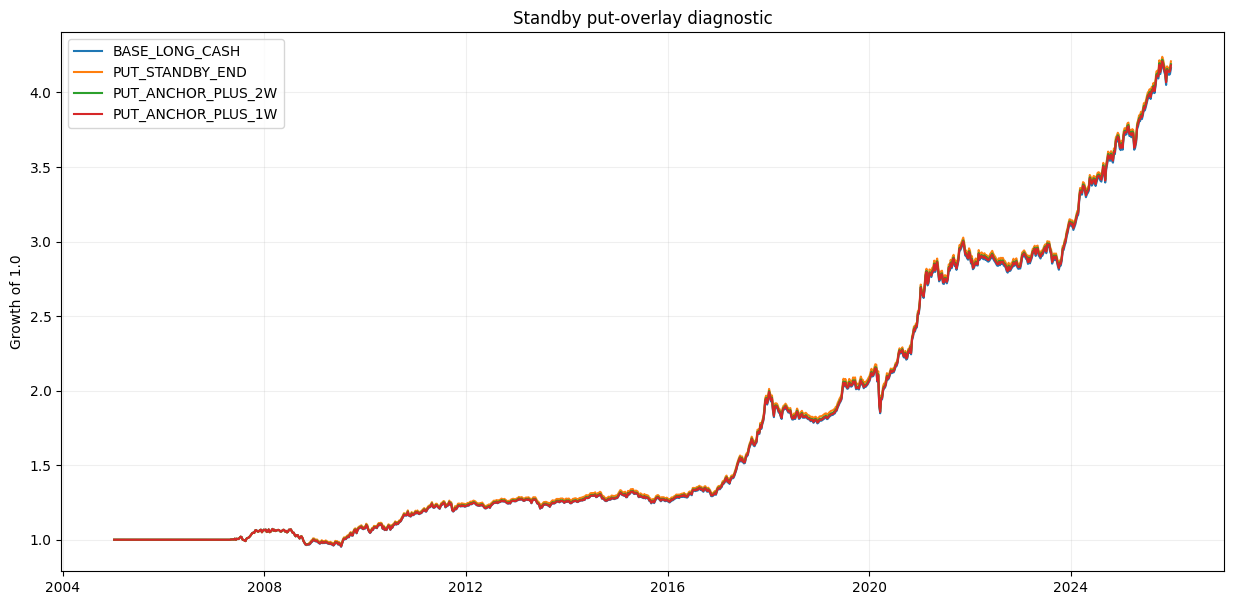

In [14]:

# ============================================================
# 4C.14 — EQUITY CURVES
# ============================================================
best_rules = (
    performance
    .drop(index="BASE_LONG_CASH")
    .sort_values("sharpe", ascending=False)
    .head(3)
    .index
    .tolist()
)

fig, ax = plt.subplots(figsize=(15, 7))

base_eq = (1 + base_port.fillna(0)).cumprod()
ax.plot(base_eq.index, base_eq, label="BASE_LONG_CASH")

for strategy in best_rules:
    rule = strategy.replace("PUT_", "")
    r = overlay_portfolios[rule]
    eq = (1 + r.fillna(0)).cumprod()
    ax.plot(eq.index, eq, label=strategy)

ax.set_title("Standby put-overlay diagnostic")
ax.set_ylabel("Growth of 1.0")
ax.legend()
ax.grid(alpha=0.2)
plt.show()



## 4C.15 Fixed stress periods

This is particularly important for an option hedge because its purpose is tail protection rather than ordinary return enhancement.


In [15]:

# ============================================================
# 4C.15 — STRESS PERIODS
# ============================================================
STRESS_PERIODS = {
    "Global Financial Crisis": ("2007-07-01", "2009-03-31"),
    "Euro-area stress": ("2011-05-01", "2012-07-31"),
    "COVID crash": ("2020-02-01", "2020-04-30"),
    "2022 inflation/rates shock": ("2022-01-01", "2022-12-31"),
}

stress_rows = []

strategies_to_test = {"BASE_LONG_CASH": base_port}
strategies_to_test.update({
    f"PUT_{rule}": r
    for rule, r in overlay_portfolios.items()
})

for period, (start, end) in STRESS_PERIODS.items():
    for strategy, r in strategies_to_test.items():
        x = r.loc[start:end].dropna()

        if len(x) == 0:
            continue

        stress_rows.append({
            "period": period,
            "strategy": strategy,
            "weeks": len(x),
            "total_return": (1 + x).prod() - 1,
            "max_drawdown": max_drawdown(x),
            "worst_week": x.min(),
        })

stress = pd.DataFrame(stress_rows)
display(stress)


,period,strategy,weeks,total_return,max_drawdown,worst_week
0,Global Financial Crisis,BASE_LONG_CASH,91,-0.025419,-0.101422,-0.020196
1,Global Financial Crisis,PUT_ANCHOR_PLUS_1W,91,-0.023036,-0.099337,-0.020196
2,Global Financial Crisis,PUT_ANCHOR_PLUS_2W,91,-0.020946,-0.096940,-0.017171
3,Global Financial Crisis,PUT_ANCHOR_PLUS_4W,91,-0.018376,-0.095658,-0.020196
4,Global Financial Crisis,PUT_ANCHOR_PLUS_8W,91,-0.014588,-0.096976,-0.020196
5,Global Financial Crisis,PUT_STANDBY_END,91,-0.013964,-0.096444,-0.020196
6,Global Financial Crisis,PUT_STANDBY_END_PLUS_2W,91,-0.014160,-0.099476,-0.020196
7,Global Financial Crisis,PUT_STANDBY_END_PLUS_4W,91,-0.011788,-0.095919,-0.020196
8,Euro-area stress,BASE_LONG_CASH,65,0.005771,-0.048228,-0.033839
9,Euro-area stress,PUT_ANCHOR_PLUS_1W,65,0.005131,-0.048228,-0.033839



## 4C.16 Save outputs

If the hedge appears promising, the next refinement should be genuine options data — not increasingly fine tuning the synthetic Black–Scholes assumptions.


In [16]:

# ============================================================
# 4C.16 — SAVE OUTPUTS
# ============================================================
EPISODES_PATH = PATHS["results"] / "04C_standby_episodes.csv"
TRADES_PATH = PATHS["results"] / "04C_synthetic_put_trades.csv"
EXIT_SUMMARY_PATH = PATHS["results"] / "04C_put_exit_rule_summary.csv"
MARKET_PATH = PATHS["results"] / "04C_market_put_summary.csv"
PERF_PATH = PATHS["results"] / "04C_put_overlay_performance.csv"
DELTA_PATH = PATHS["results"] / "04C_put_overlay_deltas.csv"
STRESS_PATH = PATHS["results"] / "04C_put_overlay_stress.csv"

episodes.to_csv(EPISODES_PATH, index=False)
trades.to_csv(TRADES_PATH, index=False)
exit_summary.to_csv(EXIT_SUMMARY_PATH)
market_rule_summary.to_csv(MARKET_PATH, index=False)
performance.to_csv(PERF_PATH)
deltas.to_csv(DELTA_PATH)
stress.to_csv(STRESS_PATH, index=False)

print("04C outputs saved.")


04C outputs saved.


In [17]:

# ============================================================
# 4C.17 — VALIDATION SUITE
# ============================================================
checks = {}

checks["holdout_absent"] = panel.index.get_level_values("date").max() <= RESEARCH_END
checks["standby_episodes_exist"] = len(episodes) > 0
checks["synthetic_put_trades_exist"] = len(trades) > 0
checks["exit_rules_tested"] = trades["exit_rule"].nunique() >= 5
checks["base_strategy_present"] = "BASE_LONG_CASH" in performance.index
checks["output_files_written"] = all(
    p.exists()
    for p in [
        EPISODES_PATH,
        TRADES_PATH,
        EXIT_SUMMARY_PATH,
        MARKET_PATH,
        PERF_PATH,
        DELTA_PATH,
        STRESS_PATH,
    ]
)

validation = pd.DataFrame({
    "check": list(checks.keys()),
    "passed": list(checks.values()),
})

print(validation.to_string(index=False))

if not all(checks.values()):
    failed = [k for k, v in checks.items() if not v]
    raise RuntimeError(f"Notebook 04C validation failed: {failed}")

print("\n" + "=" * 78)
print("NOTEBOOK 04C STATUS: PASS")
print("=" * 78)
print("Standby put-option hedge research completed.")
print("Synthetic options only — not a historical chain backtest.")
print("2026 holdout: NOT ACCESSED")
print("Main notebook sequence remains unchanged.")
print("Proceed next to Notebook 05 — Portfolio Construction.")


                     check  passed
            holdout_absent    True
    standby_episodes_exist    True
synthetic_put_trades_exist    True
         exit_rules_tested    True
     base_strategy_present    True
      output_files_written    True

NOTEBOOK 04C STATUS: PASS
Standby put-option hedge research completed.
Synthetic options only — not a historical chain backtest.
2026 holdout: NOT ACCESSED
Main notebook sequence remains unchanged.
Proceed next to Notebook 05 — Portfolio Construction.


In [18]:

# ============================================================
# 4C.18 — WRITE MANIFEST
# ============================================================
manifest = {
    "notebook_id": "04C",
    "notebook_name": "Standby Put-Option Hedge Research",
    "project_name": "SuperbCommand – Multi-Asset CTA Strategy",
    "run_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "research_end": str(RESEARCH_END.date()),
    "holdout_accessed": False,
    "option_model": "Synthetic Black-Scholes European ATM put",
    "option_maturity_weeks": OPTION_MATURITY_WEEKS,
    "vol_lookback_weeks": VOL_LOOKBACK_WEEKS,
    "risk_free_rate": RISK_FREE_RATE,
    "put_hedge_notional": PUT_HEDGE_NOTIONAL,
    "option_cost_bps": OPTION_COST_BPS,
    "exit_rules": sorted(trades["exit_rule"].unique().tolist()),
    "outputs": {
        "episodes": str(EPISODES_PATH),
        "trades": str(TRADES_PATH),
        "exit_summary": str(EXIT_SUMMARY_PATH),
        "market_summary": str(MARKET_PATH),
        "performance": str(PERF_PATH),
        "deltas": str(DELTA_PATH),
        "stress": str(STRESS_PATH),
    },
    "status": "PASS",
}

MANIFEST_PATH = PATHS["manifests"] / "04C_standby_put_option_hedge_manifest.json"

with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Saved manifest:")
print(MANIFEST_PATH)


Saved manifest:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/manifests/04C_standby_put_option_hedge_manifest.json



---

# End of Notebook 04C

## Main question

> **Does buying temporary downside protection when SuperbCommand enters Standby improve the long/cash strategy enough to justify the insurance cost?**

The notebook compares fixed exits after the Standby anchor with exits at, or shortly after, the Standby period ends.

### Important

Positive results here should be treated as a reason to acquire **real historical option data**, not as evidence that the Black–Scholes proxy itself is tradeable.

The next main notebook remains:

**Notebook 05 — Portfolio Construction**
